## Chapter 10. Building Neural Networks With Pytorch

### Pytorch Fundamentals

In [1]:
import torch

In [2]:
X = torch.tensor([[1.0, 4.0, 7.0], [2.0, 3.0, 6.0]])

In [3]:
X

tensor([[1., 4., 7.],
        [2., 3., 6.]])

In [4]:
X.shape

torch.Size([2, 3])

In [5]:
X.dtype

torch.float32

In [6]:
X[0, 1]

tensor(4.)

In [7]:
X[:, 1]

tensor([4., 3.])

In [8]:
10 * (X + 1.0) # itemwise addition and multiplication

tensor([[20., 50., 80.],
        [30., 40., 70.]])

In [9]:
X.exp() # itemwise exponential

tensor([[   2.7183,   54.5981, 1096.6332],
        [   7.3891,   20.0855,  403.4288]])

In [10]:
X.mean()

tensor(3.8333)

In [11]:
X.max(dim=0) # max values along dimension 0 (i.e., max value per column)

torch.return_types.max(
values=tensor([2., 4., 7.]),
indices=tensor([1, 0, 0]))

In [12]:
X @ X.T # matrix transpose and matrix multiplication

tensor([[66., 56.],
        [56., 49.]])

In [13]:
import numpy as np

In [14]:
X.numpy()

array([[1., 4., 7.],
       [2., 3., 6.]], dtype=float32)

In [15]:
torch.tensor(np.array([[1., 4., 7.], [2., 3., 6.]]))

tensor([[1., 4., 7.],
        [2., 3., 6.]], dtype=torch.float64)

In [16]:
torch.FloatTensor(np.array([[1., 4., 7.], [2., 3., 6]]))

tensor([[1., 4., 7.],
        [2., 3., 6.]])

In [17]:
X[:, 1] = -99
X

tensor([[  1., -99.,   7.],
        [  2., -99.,   6.]])

In [18]:
X.relu_()

tensor([[1., 0., 7.],
        [2., 0., 6.]])

### Hardware Acceleration


In [19]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

In [20]:
device

'cuda'

In [21]:
M = torch.tensor([[1., 2., 3.], [4., 5., 6.]])

In [22]:
M = M.to(device)

In [23]:
M.device

device(type='cuda', index=0)

In [24]:
M = torch.tensor([[1., 2., 3.], [4., 5., 6.]], device=device)

In [25]:
R = M @ M.T # run some operations on the GPU

In [26]:
R

tensor([[14., 32.],
        [32., 77.]], device='cuda:0')

In [27]:
M = torch.rand((1000, 1000)) # on the CPU
%timeit M @ M.T

8.51 ms ± 195 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [28]:
M = torch.rand((1000, 1000), device="cuda") # on the GPU
%timeit M @ M.T

395 μs ± 10.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


### AutoGrad

In [29]:
x = torch.tensor(5.0, requires_grad=True)

In [30]:
f = x ** 2

In [31]:
f

tensor(25., grad_fn=<PowBackward0>)

In [32]:
f.backward()

In [33]:
x.grad

tensor(10.)

In [34]:
learning_rate = 0.1
with torch.no_grad():
    if x.grad is not None:
        x -= learning_rate * x.grad
    else:
        print("x.grad is None. Did you call backward()?")

In [35]:
x_detached = x.detach()
x_detached -= learning_rate * x.grad

In [36]:
x.grad.zero_()

tensor(0.)

In [37]:
learning_rate = 0.1
x = torch.tensor(5.0, requires_grad=True)
for iteration in range(100):
    f = x ** 2 # forward pass
    f.backward() # backward pass
    with torch.no_grad():
        x -= learning_rate * x.grad # gradient descent step
x.grad.zero_()
# reset the gradients

tensor(0.)

In [38]:
x

tensor(1.1440, requires_grad=True)

In [39]:
t = torch.tensor(2.0, requires_grad=True)
z = t.exp() # this is an intermediate result
z += 1 # this is an in-place operation
#z.backward() # raises a RuntimeError!

### Implementing Linear Regression Using Pytorch Tensors

In [40]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, random_state=42)

In [41]:
X_train = torch.FloatTensor(X_train)
X_valid = torch.FloatTensor(X_valid)
X_test = torch.FloatTensor(X_test)
means = X_train.mean(dim=0, keepdims=True)
stds = X_train.std(dim=0, keepdims=True)
X_train = (X_train - means) / stds
X_valid = (X_valid - means) / stds
X_test = (X_test - means) / stds

In [42]:
y_train = torch.FloatTensor(y_train).reshape(-1, 1)
y_valid = torch.FloatTensor(y_valid).reshape(-1, 1)
y_test = torch.FloatTensor(y_test).reshape(-1, 1)

In [43]:
torch.manual_seed(42)
n_features = X_train.shape[1] # there are 8 input features
w = torch.randn((n_features, 1), requires_grad=True)
b = torch.tensor(0., requires_grad=True)

In [44]:
learning_rate = 0.4
n_epochs = 20
for epoch in range(n_epochs):
    y_pred = X_train @ w + b
    loss = ((y_pred - y_train) ** 2).mean()
    loss.backward()
    with torch.no_grad():
        b -= learning_rate * b.grad
        w -= learning_rate * w.grad
        b.grad.zero_()
        w.grad.zero_()
    print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {loss.item()}")

Epoch 1/20, Loss: 16.158456802368164
Epoch 2/20, Loss: 4.879375457763672
Epoch 3/20, Loss: 2.255225419998169
Epoch 4/20, Loss: 1.330763339996338
Epoch 5/20, Loss: 0.9680691957473755
Epoch 6/20, Loss: 0.8142675757408142
Epoch 7/20, Loss: 0.7417045831680298
Epoch 8/20, Loss: 0.7020701169967651
Epoch 9/20, Loss: 0.6765918731689453
Epoch 10/20, Loss: 0.6577964425086975
Epoch 11/20, Loss: 0.6426151394844055
Epoch 12/20, Loss: 0.6297222971916199
Epoch 13/20, Loss: 0.6184941530227661
Epoch 14/20, Loss: 0.6085968613624573
Epoch 15/20, Loss: 0.5998216271400452
Epoch 16/20, Loss: 0.592018723487854
Epoch 17/20, Loss: 0.5850691795349121
Epoch 18/20, Loss: 0.578873336315155
Epoch 19/20, Loss: 0.573345422744751
Epoch 20/20, Loss: 0.5684100389480591


In [45]:
X_new = X_test[:3]  # pretend these are new instances
with torch.no_grad():
    y_pred = X_new @ w + b  # use the trained parameters to make predictions

In [46]:
y_pred

tensor([[0.8916],
        [1.6480],
        [2.6577]])

### Linear Regression Using PyTorch’s High-Level API

In [47]:
import torch.nn as nn
# by convention, this module is usually imported this way

In [48]:
torch.manual_seed(42) # to get reproducible results
model = nn.Linear(in_features=n_features, out_features=1)

In [49]:
model.bias

Parameter containing:
tensor([0.3117], requires_grad=True)

In [50]:
model.weight

Parameter containing:
tensor([[ 0.2703,  0.2935, -0.0828,  0.3248, -0.0775,  0.0713, -0.1721,  0.2076]],
       requires_grad=True)

In [51]:
for param in model.parameters():
    print(param)

Parameter containing:
tensor([[ 0.2703,  0.2935, -0.0828,  0.3248, -0.0775,  0.0713, -0.1721,  0.2076]],
       requires_grad=True)
Parameter containing:
tensor([0.3117], requires_grad=True)


In [52]:
model(X_train[:2])

tensor([[-0.4718],
        [ 0.1131]], grad_fn=<AddmmBackward0>)

In [53]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()

In [54]:
def train_bgd(model, optimizer, criterion, X_train, y_train, n_epochs):
    for epoch in range(n_epochs):
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {loss.item()}")

In [55]:
train_bgd(model, optimizer, mse, X_train, y_train, n_epochs)

Epoch 1/20, Loss: 4.3378496170043945
Epoch 2/20, Loss: 0.7802939414978027
Epoch 3/20, Loss: 0.6253842115402222
Epoch 4/20, Loss: 0.6060435175895691
Epoch 5/20, Loss: 0.5956299304962158
Epoch 6/20, Loss: 0.587356686592102
Epoch 7/20, Loss: 0.5802990794181824
Epoch 8/20, Loss: 0.5741382241249084
Epoch 9/20, Loss: 0.5687101483345032
Epoch 10/20, Loss: 0.5639079809188843
Epoch 11/20, Loss: 0.5596511960029602
Epoch 12/20, Loss: 0.5558738112449646
Epoch 13/20, Loss: 0.5525194406509399
Epoch 14/20, Loss: 0.5495392084121704
Epoch 15/20, Loss: 0.5468900203704834
Epoch 16/20, Loss: 0.5445339679718018
Epoch 17/20, Loss: 0.5424376726150513
Epoch 18/20, Loss: 0.5405716300010681
Epoch 19/20, Loss: 0.5389097332954407
Epoch 20/20, Loss: 0.5374288558959961


In [56]:
X_new = X_test[:3]  # pretend these are new instances
with torch.no_grad():
    y_pred = model(X_new)  # use the trained model to make predictions

y_pred

tensor([[0.8061],
        [1.7116],
        [2.6973]])

### Implementing a Regression MLP

In [57]:
torch.manual_seed(42)
model = nn.Sequential(
nn.Linear(n_features, 50),
nn.ReLU(),
nn.Linear(50, 40),
nn.ReLU(),
nn.Linear(40, 1)
)

In [58]:
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()
train_bgd(model, optimizer, mse, X_train, y_train, n_epochs)

Epoch 1/20, Loss: 5.045480251312256
Epoch 2/20, Loss: 2.0523123741149902
Epoch 3/20, Loss: 1.0039883852005005
Epoch 4/20, Loss: 0.8570138216018677
Epoch 5/20, Loss: 0.7740675210952759
Epoch 6/20, Loss: 0.7225848436355591
Epoch 7/20, Loss: 0.6893726587295532
Epoch 8/20, Loss: 0.6669031977653503
Epoch 9/20, Loss: 0.650773823261261
Epoch 10/20, Loss: 0.6383934020996094
Epoch 11/20, Loss: 0.6281993389129639
Epoch 12/20, Loss: 0.6193398833274841
Epoch 13/20, Loss: 0.6113173365592957
Epoch 14/20, Loss: 0.6038705706596375
Epoch 15/20, Loss: 0.5968307852745056
Epoch 16/20, Loss: 0.5901118516921997
Epoch 17/20, Loss: 0.583646833896637
Epoch 18/20, Loss: 0.5774063467979431
Epoch 19/20, Loss: 0.5713554620742798
Epoch 20/20, Loss: 0.5654447674751282


### Implementing Mini-Batch Gradient Descent Using DataLoaders

In [59]:
from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32,
shuffle=True,pin_memory=True)

In [60]:
# extra code – build the model just like earlier
torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(n_features, 50), nn.ReLU(),
    nn.Linear(50, 40), nn.ReLU(),
    nn.Linear(40, 1)
)

model = model.to(device)

# extra code – build the optimizer and loss function, as earlier
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()

In [61]:
def train(model, optimizer, criterion, train_loader, n_epochs):
    model.train()
    for epoch in range(n_epochs):
        total_loss = 0.
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device, non_blocking=True), y_batch.to(device,non_blocking=True)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        mean_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {mean_loss:.4f}")

In [62]:
train(model, optimizer, mse, train_loader, n_epochs)

Epoch 1/20, Loss: 0.5900
Epoch 2/20, Loss: 0.4046
Epoch 3/20, Loss: 0.3801
Epoch 4/20, Loss: 0.3629
Epoch 5/20, Loss: 0.3529
Epoch 6/20, Loss: 0.3520
Epoch 7/20, Loss: 0.3408
Epoch 8/20, Loss: 0.3427
Epoch 9/20, Loss: 0.3406
Epoch 10/20, Loss: 0.3378
Epoch 11/20, Loss: 0.3304
Epoch 12/20, Loss: 0.3267
Epoch 13/20, Loss: 0.3241
Epoch 14/20, Loss: 0.3237
Epoch 15/20, Loss: 0.3189
Epoch 16/20, Loss: 0.3150
Epoch 17/20, Loss: 0.3123
Epoch 18/20, Loss: 0.3115
Epoch 19/20, Loss: 0.3090
Epoch 20/20, Loss: 0.3069


### Model Evaluation

In [63]:
def evaluate(model, data_loader, metric_fn, aggregate_fn=torch.mean):
    model.eval()
    metrics = []
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device,non_blocking=True), y_batch.to(device,non_blocking=True)
            y_pred = model(X_batch)
            metric = metric_fn(y_pred, y_batch)
            metrics.append(metric)
    return aggregate_fn(torch.stack(metrics))

In [64]:
valid_dataset = TensorDataset(X_valid, y_valid)
valid_loader = DataLoader(valid_dataset, batch_size=32,pin_memory=True)
valid_mse = evaluate(model, valid_loader, mse)
valid_mse

tensor(0.2984, device='cuda:0')

In [65]:
def rmse(y_pred, y_true):
    return ((y_pred - y_true) ** 2).mean().sqrt()

evaluate(model, valid_loader, rmse)

tensor(0.5324, device='cuda:0')

In [66]:
valid_mse.sqrt()

tensor(0.5463, device='cuda:0')

In [67]:
evaluate(model, valid_loader, mse,
            aggregate_fn=lambda metrics: torch.sqrt(torch.mean(metrics)))

tensor(0.5463, device='cuda:0')

In [68]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()  # reset the metric at the beginning
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device,non_blocking=True), y_batch.to(device,non_blocking=True)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)  # update it at each iteration
    return metric.compute()  # compute the final result at the end

In [69]:
rmse = torchmetrics.MeanSquaredError(squared=False).to(device,non_blocking=True)
evaluate_tm(model, valid_loader, rmse)

tensor(0.5463, device='cuda:0')

Epoch 1/20, train loss: 0.7826, train metric: 0.8847, valid metric: 0.6690
Epoch 2/20, train loss: 0.4362, train metric: 0.6605, valid metric: 0.6099
Epoch 3/20, train loss: 0.3930, train metric: 0.6269, valid metric: 0.6145
Epoch 4/20, train loss: 0.3759, train metric: 0.6132, valid metric: 0.5963
Epoch 5/20, train loss: 0.3649, train metric: 0.6040, valid metric: 0.5911
Epoch 6/20, train loss: 0.3598, train metric: 0.5999, valid metric: 0.5965
Epoch 7/20, train loss: 0.3530, train metric: 0.5941, valid metric: 0.6061
Epoch 8/20, train loss: 0.3495, train metric: 0.5911, valid metric: 0.6043
Epoch 9/20, train loss: 0.3455, train metric: 0.5877, valid metric: 0.5723
Epoch 10/20, train loss: 0.3416, train metric: 0.5846, valid metric: 0.6043
Epoch 11/20, train loss: 0.3401, train metric: 0.5831, valid metric: 0.5882
Epoch 12/20, train loss: 0.3362, train metric: 0.5799, valid metric: 0.5738
Epoch 13/20, train loss: 0.3352, train metric: 0.5788, valid metric: 0.5873
Epoch 14/20, train lo

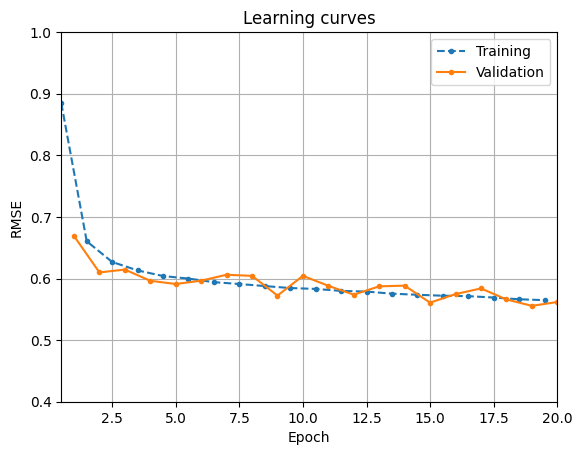

In [70]:
def train2(model, optimizer, criterion, metric, train_loader, valid_loader,
                n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(device,non_blocking=True), y_batch.to(device,non_blocking=True)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
                f"train loss: {history['train_losses'][-1]:.4f}, "
                f"train metric: {history['train_metrics'][-1]:.4f}, "
                f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

torch.manual_seed(42)
learning_rate = 0.01
model = nn.Sequential(
    nn.Linear(n_features, 50), nn.ReLU(),
    nn.Linear(50, 40), nn.ReLU(),
    nn.Linear(40, 30), nn.ReLU(),
    nn.Linear(30, 1)
)
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device,non_blocking=True)
history = train2(model, optimizer, mse, rmse, train_loader, valid_loader,
                    n_epochs)

import matplotlib.pyplot as plt
# Since we compute the training metric
plt.plot(np.arange(n_epochs) + 0.5, history["train_metrics"], ".--",
            label="Training")
plt.plot(np.arange(n_epochs) + 1.0, history["valid_metrics"], ".-",
            label="Validation")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.grid()
plt.title("Learning curves")
plt.axis((0.5, 20, 0.4, 1.0))
plt.legend()
plt.show()

### Building Nonsequential Models Using Custom Modules

In [71]:
class WideAndDeep(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.deep_stack = nn.Sequential(
            nn.Linear(n_features, 50), nn.ReLU(),
            nn.Linear(50, 40), nn.ReLU(),
            nn.Linear(40, 30), nn.ReLU(),
        )
        self.output_layer = nn.Linear(30 + n_features, 1)

    def forward(self, X):
        deep_output = self.deep_stack(X)
        wide_and_deep = torch.concat([X, deep_output], dim=1)
        return self.output_layer(wide_and_deep)

In [72]:
torch.manual_seed(42)
model = WideAndDeep(n_features).to(device,non_blocking=True)
learning_rate = 0.002  # the model changed, so did the optimal learning rate

In [73]:
# extra code: train the model, exactly our previous models
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device,non_blocking=True)
history = train2(model, optimizer, mse, rmse, train_loader, valid_loader,
                    n_epochs)

Epoch 1/20, train loss: 1.7802, train metric: 1.3344, valid metric: 0.8690
Epoch 2/20, train loss: 0.6201, train metric: 0.7875, valid metric: 0.9492
Epoch 3/20, train loss: 0.5900, train metric: 0.7682, valid metric: 0.7331
Epoch 4/20, train loss: 0.5607, train metric: 0.7488, valid metric: 0.7771
Epoch 5/20, train loss: 0.5408, train metric: 0.7353, valid metric: 0.7967
Epoch 6/20, train loss: 0.5244, train metric: 0.7241, valid metric: 0.7098
Epoch 7/20, train loss: 0.5070, train metric: 0.7119, valid metric: 0.7419
Epoch 8/20, train loss: 0.4941, train metric: 0.7030, valid metric: 0.6750
Epoch 9/20, train loss: 0.4798, train metric: 0.6928, valid metric: 0.6762
Epoch 10/20, train loss: 0.4657, train metric: 0.6825, valid metric: 0.6678
Epoch 11/20, train loss: 0.4538, train metric: 0.6736, valid metric: 0.6617
Epoch 12/20, train loss: 0.4441, train metric: 0.6665, valid metric: 0.6651
Epoch 13/20, train loss: 0.4328, train metric: 0.6580, valid metric: 0.6803
Epoch 14/20, train lo

In [74]:
class WideAndDeepV2(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.deep_stack = nn.Sequential(
            nn.Linear(n_features - 2, 50), nn.ReLU(),
            nn.Linear(50, 40), nn.ReLU(),
            nn.Linear(40, 30), nn.ReLU(),
        )
        self.output_layer = nn.Linear(30 + 5, 1)

    def forward(self, X):
        X_wide = X[:, :5]
        X_deep = X[:, 2:]
        deep_output = self.deep_stack(X_deep)
        wide_and_deep = torch.concat([X_wide, deep_output], dim=1)
        return self.output_layer(wide_and_deep)

In [75]:
torch.manual_seed(42)
model = WideAndDeepV2(n_features).to(device,non_blocking=True)

In [76]:
# extra code: train the model, exactly our previous models
learning_rate = 0.002
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device,non_blocking=True)
history = train2(model, optimizer, mse, rmse, train_loader, valid_loader,
                    n_epochs)

Epoch 1/20, train loss: 1.8482, train metric: 1.3598, valid metric: 0.9100
Epoch 2/20, train loss: 0.6282, train metric: 0.7927, valid metric: 0.8028
Epoch 3/20, train loss: 0.5763, train metric: 0.7591, valid metric: 0.7567
Epoch 4/20, train loss: 0.5413, train metric: 0.7356, valid metric: 0.7290
Epoch 5/20, train loss: 0.5099, train metric: 0.7142, valid metric: 0.7011
Epoch 6/20, train loss: 0.4841, train metric: 0.6958, valid metric: 0.6816
Epoch 7/20, train loss: 0.4656, train metric: 0.6824, valid metric: 0.6670
Epoch 8/20, train loss: 0.4526, train metric: 0.6728, valid metric: 0.6576
Epoch 9/20, train loss: 0.4438, train metric: 0.6662, valid metric: 0.6539
Epoch 10/20, train loss: 0.4380, train metric: 0.6618, valid metric: 0.6498
Epoch 11/20, train loss: 0.4326, train metric: 0.6577, valid metric: 0.6470
Epoch 12/20, train loss: 0.4284, train metric: 0.6546, valid metric: 0.6447
Epoch 13/20, train loss: 0.4253, train metric: 0.6521, valid metric: 0.6452
Epoch 14/20, train lo

### Building Models with Multiple Inputs

In [77]:
class WideAndDeepV3(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.deep_stack = nn.Sequential(
            nn.Linear(n_features - 2, 50), nn.ReLU(),
            nn.Linear(50, 40), nn.ReLU(),
            nn.Linear(40, 30), nn.ReLU(),
        )
        self.output_layer = nn.Linear(30 + 5, 1)

    def forward(self, X_wide, X_deep):
        deep_output = self.deep_stack(X_deep)
        wide_and_deep = torch.concat([X_wide, deep_output], dim=1)
        return self.output_layer(wide_and_deep)

In [78]:
torch.manual_seed(42)
train_data_wd = TensorDataset(X_train[:, :5], X_train[:, 2:], y_train)
train_loader_wd = DataLoader(train_data_wd, batch_size=32, shuffle=True,pin_memory=True)
valid_data_wd = TensorDataset(X_valid[:, :5], X_valid[:, 2:], y_valid)
valid_loader_wd = DataLoader(valid_data_wd, batch_size=32,pin_memory=True)
test_data_wd = TensorDataset(X_test[:, :5], X_test[:, 2:], y_test)
test_loader_wd = DataLoader(test_data_wd, batch_size=32,pin_memory=True)

In [79]:
def evaluate_multi_in(model, data_loader, metric):
    model.eval()
    metric.reset()  # reset the metric at the beginning
    with torch.no_grad():
        for X_batch_wide, X_batch_deep, y_batch in data_loader:
            X_batch_wide = X_batch_wide.to(device,non_blocking=True)
            X_batch_deep = X_batch_deep.to(device,non_blocking=True)
            y_batch = y_batch.to(device,non_blocking=True)
            y_pred = model(X_batch_wide, X_batch_deep)
            metric.update(y_pred, y_batch)  # update it at each iteration
    return metric.compute()  # compute the final result at the end
def train_multi_in(model, optimizer, criterion, metric, train_loader,
                    valid_loader, n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for *X_batch_inputs, y_batch in train_loader:
            model.train()
            X_batch_inputs = [X.to(device, non_blocking=True) for X in X_batch_inputs]
            y_batch = y_batch.to(device,non_blocking=True)
            y_pred = model(*X_batch_inputs)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_multi_in(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
                f"train loss: {history['train_losses'][-1]:.4f}, "
                f"train metric: {history['train_metrics'][-1]:.4f}, "
                f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

torch.manual_seed(42)
learning_rate = 0.01
model = WideAndDeepV3(n_features).to(device,non_blocking=True)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device,non_blocking=True)
history = train_multi_in(model, optimizer, mse, rmse, train_loader_wd,
                            valid_loader_wd, n_epochs)

Epoch 1/20, train loss: 0.8366, train metric: 0.9148, valid metric: 0.6892
Epoch 2/20, train loss: 0.4627, train metric: 0.6803, valid metric: 0.6455
Epoch 3/20, train loss: 0.4319, train metric: 0.6572, valid metric: 0.6374
Epoch 4/20, train loss: 0.4259, train metric: 0.6525, valid metric: 0.6512
Epoch 5/20, train loss: 0.4120, train metric: 0.6420, valid metric: 0.6305
Epoch 6/20, train loss: 0.4040, train metric: 0.6356, valid metric: 0.6287
Epoch 7/20, train loss: 0.4005, train metric: 0.6330, valid metric: 0.6252
Epoch 8/20, train loss: 0.3976, train metric: 0.6306, valid metric: 0.6158
Epoch 9/20, train loss: 0.3883, train metric: 0.6230, valid metric: 0.7407
Epoch 10/20, train loss: 0.3866, train metric: 0.6218, valid metric: 0.6063
Epoch 11/20, train loss: 0.3752, train metric: 0.6125, valid metric: 0.5974
Epoch 12/20, train loss: 0.3704, train metric: 0.6087, valid metric: 0.5887
Epoch 13/20, train loss: 0.3677, train metric: 0.6063, valid metric: 0.5978
Epoch 14/20, train lo

In [80]:
class WideAndDeepDataset(torch.utils.data.Dataset):
    def __init__(self, X_wide, X_deep, y):
        self.X_wide = X_wide
        self.X_deep = X_deep
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        input_dict = {"X_wide": self.X_wide[idx], "X_deep": self.X_deep[idx]}
        return input_dict, self.y[idx]

In [81]:
torch.manual_seed(42)
train_data_named = WideAndDeepDataset(
    X_wide=X_train[:, :5], X_deep=X_train[:, 2:], y=y_train)
train_loader_named = DataLoader(train_data_named, batch_size=32, shuffle=True,pin_memory=True)
valid_data_named = WideAndDeepDataset(
    X_wide=X_valid[:, :5], X_deep=X_valid[:, 2:], y=y_valid)
valid_loader_named = DataLoader(valid_data_named, batch_size=32,pin_memory=True)
test_data_named = WideAndDeepDataset(
    X_wide=X_test[:, :5], X_deep=X_test[:, 2:], y=y_test)
test_loader_named = DataLoader(test_data_named, batch_size=32,pin_memory=True)

In [82]:
def evaluate_named(model, data_loader, metric):
    model.eval()
    metric.reset()  # reset the metric at the beginning
    with torch.no_grad():
        for inputs, y_batch in data_loader:
            inputs = {name: X.to(device,non_blocking=True) for name, X in inputs.items()}
            y_batch = y_batch.to(device,non_blocking=True)
            y_pred = model(X_wide=inputs["X_wide"], X_deep=inputs["X_deep"])
            metric.update(y_pred, y_batch)
    return metric.compute()  # compute the final result at the end

def train_named(model, optimizer, criterion, metric, train_loader,
                    valid_loader, n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for inputs, y_batch in train_loader:
            model.train()
            inputs = {name: X.to(device,non_blocking=True) for name, X in inputs.items()}
            y_batch = y_batch.to(device,non_blocking=True)
            y_pred = model(**inputs)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_named(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
                f"train loss: {history['train_losses'][-1]:.4f}, "
                f"train metric: {history['train_metrics'][-1]:.4f}, "
                f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

torch.manual_seed(42)
learning_rate = 0.01
model = WideAndDeepV3(n_features).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train_named(model, optimizer, mse, rmse, train_loader_named,
                            valid_loader_named, n_epochs)

Epoch 1/20, train loss: 0.8366, train metric: 0.9148, valid metric: 0.6892
Epoch 2/20, train loss: 0.4627, train metric: 0.6803, valid metric: 0.6455
Epoch 3/20, train loss: 0.4319, train metric: 0.6572, valid metric: 0.6374
Epoch 4/20, train loss: 0.4259, train metric: 0.6525, valid metric: 0.6512
Epoch 5/20, train loss: 0.4120, train metric: 0.6420, valid metric: 0.6305
Epoch 6/20, train loss: 0.4040, train metric: 0.6356, valid metric: 0.6287
Epoch 7/20, train loss: 0.4005, train metric: 0.6330, valid metric: 0.6252
Epoch 8/20, train loss: 0.3976, train metric: 0.6306, valid metric: 0.6158
Epoch 9/20, train loss: 0.3883, train metric: 0.6230, valid metric: 0.7407
Epoch 10/20, train loss: 0.3866, train metric: 0.6218, valid metric: 0.6063
Epoch 11/20, train loss: 0.3752, train metric: 0.6125, valid metric: 0.5974
Epoch 12/20, train loss: 0.3704, train metric: 0.6087, valid metric: 0.5887
Epoch 13/20, train loss: 0.3677, train metric: 0.6063, valid metric: 0.5978
Epoch 14/20, train lo

### Building Models with Multiple Outputs

In [83]:
class WideAndDeepV4(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.deep_stack = nn.Sequential(
            nn.Linear(n_features - 2, 50), nn.ReLU(),
            nn.Linear(50, 40), nn.ReLU(),
            nn.Linear(40, 30), nn.ReLU(),
        )
        self.output_layer = nn.Linear(30 + 5, 1)
        self.aux_output_layer = nn.Linear(30, 1)

    def forward(self, X_wide, X_deep):
        deep_output = self.deep_stack(X_deep)
        wide_and_deep = torch.concat([X_wide, deep_output], dim=1)
        main_output = self.output_layer(wide_and_deep)
        aux_output = self.aux_output_layer(deep_output)
        return main_output, aux_output

In [84]:
import torchmetrics

def evaluate_multi_out(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for inputs, y_batch in data_loader:
            inputs = {name: X.to(device) for name, X in inputs.items()}
            y_batch = y_batch.to(device)
            y_pred, _ = model(**inputs)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train_multi_out(model, optimizer, criterion, metric, train_loader,
                    valid_loader, n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for inputs, y_batch in train_loader:
            model.train()
            inputs = {name: X.to(device) for name, X in inputs.items()}
            y_batch = y_batch.to(device)
            y_pred, y_pred_aux = model(**inputs)
            main_loss = criterion(y_pred, y_batch)
            aux_loss = criterion(y_pred_aux, y_batch)
            loss = 0.8 * main_loss + 0.2 * aux_loss
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_multi_out(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
                f"train loss: {history['train_losses'][-1]:.4f}, "
                f"train metric: {history['train_metrics'][-1]:.4f}, "
                f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

torch.manual_seed(42)
learning_rate = 0.01
model = WideAndDeepV4(n_features).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train_multi_out(model, optimizer, mse, rmse, train_loader_named,
                            valid_loader_named, n_epochs)

Epoch 1/20, train loss: 1.0693, train metric: 0.9506, valid metric: 0.7085
Epoch 2/20, train loss: 0.5817, train metric: 0.6946, valid metric: 0.6607
Epoch 3/20, train loss: 0.5010, train metric: 0.6581, valid metric: 0.6425
Epoch 4/20, train loss: 0.4690, train metric: 0.6497, valid metric: 0.6654
Epoch 5/20, train loss: 0.4503, train metric: 0.6420, valid metric: 0.6338
Epoch 6/20, train loss: 0.4387, train metric: 0.6373, valid metric: 0.6563
Epoch 7/20, train loss: 0.4315, train metric: 0.6330, valid metric: 0.6193
Epoch 8/20, train loss: 0.4249, train metric: 0.6302, valid metric: 0.6167
Epoch 9/20, train loss: 0.4116, train metric: 0.6202, valid metric: 0.6450
Epoch 10/20, train loss: 0.4085, train metric: 0.6198, valid metric: 0.5938
Epoch 11/20, train loss: 0.4073, train metric: 0.6196, valid metric: 0.5959
Epoch 12/20, train loss: 0.3914, train metric: 0.6077, valid metric: 0.6074
Epoch 13/20, train loss: 0.3846, train metric: 0.6033, valid metric: 0.5813
Epoch 14/20, train lo

### Building an Image Classifier with PyTorch

In [85]:
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(train_and_valid_data, [55_000, 5_000])

In [86]:
torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True,pin_memory=True)
valid_loader = DataLoader(valid_data, batch_size=32,pin_memory=True)
test_loader = DataLoader(test_data, batch_size=32,pin_memory=True)

In [87]:
X_sample, y_sample = train_data[0]

In [88]:
X_sample.shape

torch.Size([1, 28, 28])

In [89]:
X_sample.dtype

torch.float32

In [90]:
train_and_valid_data.classes[y_sample]

'Ankle boot'

### Building The Classifier

In [91]:
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes)
        )

    def forward(self, X):
        return self.mlp(X)

torch.manual_seed(42)
model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=300, n_hidden2=100,
                        n_classes=10).to(device,non_blocking=True)
xentropy = nn.CrossEntropyLoss()

In [92]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device,non_blocking=True)
_ = train2(model, optimizer, xentropy, accuracy, train_loader, valid_loader,
            n_epochs)

Epoch 1/20, train loss: 0.6059, train metric: 0.7811, valid metric: 0.8432
Epoch 2/20, train loss: 0.4057, train metric: 0.8499, valid metric: 0.8440
Epoch 3/20, train loss: 0.3629, train metric: 0.8660, valid metric: 0.8540
Epoch 4/20, train loss: 0.3358, train metric: 0.8759, valid metric: 0.8632
Epoch 5/20, train loss: 0.3142, train metric: 0.8841, valid metric: 0.8750
Epoch 6/20, train loss: 0.2990, train metric: 0.8875, valid metric: 0.8660
Epoch 7/20, train loss: 0.2848, train metric: 0.8927, valid metric: 0.8748
Epoch 8/20, train loss: 0.2735, train metric: 0.8967, valid metric: 0.8772
Epoch 9/20, train loss: 0.2629, train metric: 0.9016, valid metric: 0.8792
Epoch 10/20, train loss: 0.2534, train metric: 0.9045, valid metric: 0.8824
Epoch 11/20, train loss: 0.2461, train metric: 0.9080, valid metric: 0.8844
Epoch 12/20, train loss: 0.2352, train metric: 0.9102, valid metric: 0.8870
Epoch 13/20, train loss: 0.2283, train metric: 0.9132, valid metric: 0.8860
Epoch 14/20, train lo

In [93]:
model.eval()
X_new, y_new = next(iter(valid_loader))
X_new = X_new[:3].to(device)
with torch.no_grad():
    y_pred_logits = model(X_new)
y_pred = y_pred_logits.argmax(dim=1)  # index of the largest logit
y_pred

tensor([7, 4, 2], device='cuda:0')

In [94]:
[train_and_valid_data.classes[index] for index in y_pred]

['Sneaker', 'Coat', 'Pullover']

In [95]:
import torch.nn.functional as F

In [96]:
y_proba = F.softmax(y_pred_logits, dim=1)

In [97]:
y_proba.round(decimals=3)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0210, 0.0000, 0.7100, 0.0000,
         0.2690],
        [0.0000, 0.0000, 0.0030, 0.0000, 0.9970, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0040, 0.0000, 0.6190, 0.0010, 0.2850, 0.0000, 0.0900, 0.0000, 0.0020,
         0.0000]], device='cuda:0')

In [98]:
y_top4_values, y_top4_indices = torch.topk(y_pred_logits, k=4, dim=1)
y_top4_probas = F.softmax(y_top4_values, dim=1)
if device == "mps":
    y_top4_probas = y_top4_probas.cpu()
y_top4_probas.round(decimals=3)

tensor([[0.7100, 0.2690, 0.0210, 0.0000],
        [0.9970, 0.0030, 0.0000, 0.0000],
        [0.6210, 0.2850, 0.0900, 0.0040]], device='cuda:0')

In [99]:
y_top4_indices

tensor([[7, 9, 5, 8],
        [4, 2, 6, 8],
        [2, 4, 6, 0]], device='cuda:0')

In [100]:
sum([param.numel() for param in model.parameters()])


266610

## Fine-Tuning Neural Network

### Hyperparameters with Optuna

In [101]:
import optuna

def objective(trial):
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    n_hidden = trial.suggest_int("n_hidden", 20, 300)
    model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=n_hidden,
                            n_hidden2=n_hidden, n_classes=10).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    xentropy = nn.CrossEntropyLoss()
    accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10)
    accuracy = accuracy.to(device)
    history = train2(model, optimizer, xentropy, accuracy, train_loader,
                        valid_loader, n_epochs=10)
    validation_accuracy = max(history["valid_metrics"])
    return validation_accuracy

In [102]:
torch.manual_seed(42)
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=5)

[I 2025-11-15 19:58:02,928] A new study created in memory with name: no-name-b48b56ca-bc25-4d64-a842-909e6d259efd


Epoch 1/10, train loss: 2.2769, train metric: 0.1471, valid metric: 0.1860
Epoch 2/10, train loss: 2.2093, train metric: 0.2794, valid metric: 0.3500
Epoch 3/10, train loss: 2.1164, train metric: 0.4110, valid metric: 0.4554
Epoch 4/10, train loss: 1.9776, train metric: 0.5137, valid metric: 0.5560
Epoch 5/10, train loss: 1.7867, train metric: 0.5826, valid metric: 0.6026
Epoch 6/10, train loss: 1.5775, train metric: 0.6184, valid metric: 0.6228
Epoch 7/10, train loss: 1.3978, train metric: 0.6288, valid metric: 0.6324
Epoch 8/10, train loss: 1.2605, train metric: 0.6360, valid metric: 0.6372
Epoch 9/10, train loss: 1.1572, train metric: 0.6468, valid metric: 0.6424


[I 2025-11-15 20:02:52,007] Trial 0 finished with value: 0.6435999870300293 and parameters: {'learning_rate': 0.00031489116479568613, 'n_hidden': 287}. Best is trial 0 with value: 0.6435999870300293.


Epoch 10/10, train loss: 1.0782, train metric: 0.6537, valid metric: 0.6436
Epoch 1/10, train loss: 1.1459, train metric: 0.6227, valid metric: 0.7338
Epoch 2/10, train loss: 0.6108, train metric: 0.7842, valid metric: 0.7998
Epoch 3/10, train loss: 0.5203, train metric: 0.8169, valid metric: 0.8094
Epoch 4/10, train loss: 0.4810, train metric: 0.8302, valid metric: 0.8312
Epoch 5/10, train loss: 0.4558, train metric: 0.8403, valid metric: 0.8348
Epoch 6/10, train loss: 0.4388, train metric: 0.8461, valid metric: 0.8440
Epoch 7/10, train loss: 0.4240, train metric: 0.8513, valid metric: 0.8414
Epoch 8/10, train loss: 0.4123, train metric: 0.8563, valid metric: 0.8508
Epoch 9/10, train loss: 0.3998, train metric: 0.8599, valid metric: 0.8536


[I 2025-11-15 20:07:35,459] Trial 1 finished with value: 0.8546000123023987 and parameters: {'learning_rate': 0.008471801418819975, 'n_hidden': 188}. Best is trial 1 with value: 0.8546000123023987.


...

Epoch 10/10, train loss: 2.2414, train metric: 0.2299, valid metric: 0.2334
Epoch 1/10, train loss: 2.3035, train metric: 0.1373, valid metric: 0.1526
Epoch 2/10, train loss: 2.3005, train metric: 0.1569, valid metric: 0.1724
Epoch 3/10, train loss: 2.2975, train metric: 0.1755, valid metric: 0.1896
Epoch 4/10, train loss: 2.2945, train metric: 0.1941, valid metric: 0.2132
Epoch 5/10, train loss: 2.2914, train metric: 0.2105, valid metric: 0.2288
Epoch 6/10, train loss: 2.2884, train metric: 0.2261, valid metric: 0.2418
Epoch 7/10, train loss: 2.2853, train metric: 0.2419, valid metric: 0.2580
Epoch 8/10, train loss: 2.2823, train metric: 0.2581, valid metric: 0.2742
Epoch 9/10, train loss: 2.2792, train metric: 0.2736, valid metric: 0.2918


[I 2025-11-15 20:16:52,831] Trial 3 finished with value: 0.30959999561309814 and parameters: {'learning_rate': 1.7073967431528103e-05, 'n_hidden': 263}. Best is trial 1 with value: 0.8546000123023987.


Epoch 10/10, train loss: 2.2761, train metric: 0.2897, valid metric: 0.3096
Epoch 1/10, train loss: 1.8379, train metric: 0.4869, valid metric: 0.6208
Epoch 2/10, train loss: 0.9751, train metric: 0.6666, valid metric: 0.6978
Epoch 3/10, train loss: 0.7608, train metric: 0.7253, valid metric: 0.7416
Epoch 4/10, train loss: 0.6704, train metric: 0.7639, valid metric: 0.7720
Epoch 5/10, train loss: 0.6108, train metric: 0.7913, valid metric: 0.7904
Epoch 6/10, train loss: 0.5686, train metric: 0.8054, valid metric: 0.8050
Epoch 7/10, train loss: 0.5385, train metric: 0.8164, valid metric: 0.8082
Epoch 8/10, train loss: 0.5158, train metric: 0.8243, valid metric: 0.8216
Epoch 9/10, train loss: 0.4988, train metric: 0.8280, valid metric: 0.8222


[I 2025-11-15 20:21:30,269] Trial 4 finished with value: 0.8222000002861023 and parameters: {'learning_rate': 0.002537815508265664, 'n_hidden': 218}. Best is trial 1 with value: 0.8546000123023987.


Epoch 10/10, train loss: 0.4842, train metric: 0.8330, valid metric: 0.8092


In [103]:
study.best_params

{'learning_rate': 0.008471801418819975, 'n_hidden': 188}

In [104]:
study.best_value

0.8546000123023987

In [105]:
def objective(trial, train_loader, valid_loader):
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    n_hidden = trial.suggest_int("n_hidden", 20, 300)
    model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=n_hidden,
                            n_hidden2=n_hidden, n_classes=10).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    xentropy = nn.CrossEntropyLoss()
    accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10)
    accuracy = accuracy.to(device)
    best_validation_accuracy = 0.0
    for epoch in range(n_epochs):
        history = train2(model, optimizer, xentropy, accuracy, train_loader,
                            valid_loader, n_epochs=1)
        validation_accuracy = max(history["valid_metrics"])
        if validation_accuracy > best_validation_accuracy:
            best_validation_accuracy = validation_accuracy
        trial.report(validation_accuracy, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return best_validation_accuracy

In [106]:
objective_with_data = lambda trial: objective(
    trial, train_loader=train_loader, valid_loader=valid_loader)

In [107]:
from functools import partial

objective_with_data = partial(objective, train_loader=train_loader,
                                valid_loader=valid_loader)

In [108]:
torch.manual_seed(42)
sampler = optuna.samplers.TPESampler(seed=42)
pruner = optuna.pruners.MedianPruner()
study = optuna.create_study(direction="maximize", sampler=sampler,
                            pruner=pruner)
study.optimize(objective_with_data, n_trials=5)# n_trials previous 20

[I 2025-11-15 20:21:30,448] A new study created in memory with name: no-name-a81194f7-958c-4f31-8997-09ca0c3ddc97


Epoch 1/1, train loss: 2.2769, train metric: 0.1471, valid metric: 0.1860
Epoch 1/1, train loss: 2.2093, train metric: 0.2794, valid metric: 0.3500
Epoch 1/1, train loss: 2.1164, train metric: 0.4110, valid metric: 0.4554
Epoch 1/1, train loss: 1.9776, train metric: 0.5137, valid metric: 0.5560
Epoch 1/1, train loss: 1.7867, train metric: 0.5826, valid metric: 0.6026
Epoch 1/1, train loss: 1.5775, train metric: 0.6184, valid metric: 0.6228
Epoch 1/1, train loss: 1.3978, train metric: 0.6288, valid metric: 0.6324
Epoch 1/1, train loss: 1.2605, train metric: 0.6360, valid metric: 0.6372
Epoch 1/1, train loss: 1.1572, train metric: 0.6468, valid metric: 0.6424
Epoch 1/1, train loss: 1.0782, train metric: 0.6537, valid metric: 0.6436
Epoch 1/1, train loss: 1.0162, train metric: 0.6611, valid metric: 0.6530
Epoch 1/1, train loss: 0.9665, train metric: 0.6689, valid metric: 0.6620
Epoch 1/1, train loss: 0.9258, train metric: 0.6761, valid metric: 0.6700
Epoch 1/1, train loss: 0.8919, train m

[I 2025-11-15 20:30:22,139] Trial 0 finished with value: 0.7089999914169312 and parameters: {'learning_rate': 0.00031489116479568613, 'n_hidden': 287}. Best is trial 0 with value: 0.7089999914169312.


Epoch 1/1, train loss: 0.7647, train metric: 0.7196, valid metric: 0.7082
Epoch 1/1, train loss: 1.1485, train metric: 0.6157, valid metric: 0.7330
Epoch 1/1, train loss: 0.6133, train metric: 0.7863, valid metric: 0.8082
Epoch 1/1, train loss: 0.5200, train metric: 0.8180, valid metric: 0.8134
Epoch 1/1, train loss: 0.4783, train metric: 0.8312, valid metric: 0.8232
Epoch 1/1, train loss: 0.4533, train metric: 0.8401, valid metric: 0.8020
Epoch 1/1, train loss: 0.4357, train metric: 0.8465, valid metric: 0.8446
Epoch 1/1, train loss: 0.4211, train metric: 0.8510, valid metric: 0.8274
Epoch 1/1, train loss: 0.4084, train metric: 0.8563, valid metric: 0.8398
Epoch 1/1, train loss: 0.3982, train metric: 0.8606, valid metric: 0.8530
Epoch 1/1, train loss: 0.3883, train metric: 0.8637, valid metric: 0.8586
Epoch 1/1, train loss: 0.3784, train metric: 0.8662, valid metric: 0.8544
Epoch 1/1, train loss: 0.3700, train metric: 0.8695, valid metric: 0.8560
Epoch 1/1, train loss: 0.3633, train m

[I 2025-11-15 20:38:47,146] Trial 1 finished with value: 0.8669999837875366 and parameters: {'learning_rate': 0.008471801418819975, 'n_hidden': 188}. Best is trial 1 with value: 0.8669999837875366.


...

Epoch 1/1, train loss: 2.1751, train metric: 0.2610, valid metric: 0.2538
Epoch 1/1, train loss: 2.3015, train metric: 0.0997, valid metric: 0.1028
Epoch 1/1, train loss: 2.2984, train metric: 0.1009, valid metric: 0.1050
Epoch 1/1, train loss: 2.2953, train metric: 0.1051, valid metric: 0.1124
Epoch 1/1, train loss: 2.2923, train metric: 0.1160, valid metric: 0.1270
Epoch 1/1, train loss: 2.2894, train metric: 0.1347, valid metric: 0.1496
Epoch 1/1, train loss: 2.2865, train metric: 0.1548, valid metric: 0.1652
Epoch 1/1, train loss: 2.2837, train metric: 0.1699, valid metric: 0.1800
Epoch 1/1, train loss: 2.2808, train metric: 0.1800, valid metric: 0.1872
Epoch 1/1, train loss: 2.2780, train metric: 0.1855, valid metric: 0.1916
Epoch 1/1, train loss: 2.2752, train metric: 0.1893, valid metric: 0.1960
Epoch 1/1, train loss: 2.2725, train metric: 0.1950, valid metric: 0.2008
Epoch 1/1, train loss: 2.2697, train metric: 0.2000, valid metric: 0.2026
Epoch 1/1, train loss: 2.2669, train m

[I 2025-11-15 20:57:00,980] Trial 3 finished with value: 0.23960000276565552 and parameters: {'learning_rate': 1.7073967431528103e-05, 'n_hidden': 263}. Best is trial 1 with value: 0.8669999837875366.


Epoch 1/1, train loss: 2.2469, train metric: 0.2429, valid metric: 0.2396
Epoch 1/1, train loss: 1.8945, train metric: 0.4923, valid metric: 0.6290
Epoch 1/1, train loss: 1.0016, train metric: 0.6582, valid metric: 0.6772
Epoch 1/1, train loss: 0.7747, train metric: 0.7115, valid metric: 0.7248
Epoch 1/1, train loss: 0.6864, train metric: 0.7551, valid metric: 0.7594
Epoch 1/1, train loss: 0.6268, train metric: 0.7833, valid metric: 0.7806
Epoch 1/1, train loss: 0.5830, train metric: 0.7999, valid metric: 0.7862
Epoch 1/1, train loss: 0.5500, train metric: 0.8113, valid metric: 0.8064
Epoch 1/1, train loss: 0.5252, train metric: 0.8184, valid metric: 0.8130
Epoch 1/1, train loss: 0.5061, train metric: 0.8238, valid metric: 0.8204
Epoch 1/1, train loss: 0.4908, train metric: 0.8291, valid metric: 0.8206
Epoch 1/1, train loss: 0.4777, train metric: 0.8338, valid metric: 0.8150
Epoch 1/1, train loss: 0.4681, train metric: 0.8374, valid metric: 0.8304
Epoch 1/1, train loss: 0.4591, train m

[I 2025-11-15 21:06:26,107] Trial 4 finished with value: 0.8429999947547913 and parameters: {'learning_rate': 0.002537815508265664, 'n_hidden': 218}. Best is trial 1 with value: 0.8669999837875366.


Epoch 1/1, train loss: 0.4173, train metric: 0.8556, valid metric: 0.8430


In [109]:
study.best_value

0.8669999837875366

In [110]:
study.best_params

{'learning_rate': 0.008471801418819975, 'n_hidden': 188}

### Saving and Loading PyTorch Models

In [111]:
torch.save(model, "my_fashion_mnist.pt")

In [112]:
loaded_model = torch.load("my_fashion_mnist.pt", weights_only=False)

In [113]:
loaded_model.eval()
y_pred_logits = loaded_model(X_new)

In [114]:
torch.save(model.state_dict(), "my_fashion_mnist_weights.pt")

In [115]:
type(model.state_dict())

collections.OrderedDict

In [116]:
new_model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=300, n_hidden2=100,
                            n_classes=10)
loaded_weights = torch.load("my_fashion_mnist_weights.pt", weights_only=True)
new_model.load_state_dict(loaded_weights)
new_model.eval()

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)

In [117]:
model_data = {
    "model_state_dict": model.state_dict(),
    "model_hyperparameters": {
        "n_inputs": 1 * 28 * 28,
        "n_hidden1": 300,
        "n_hidden2": 100,
        "n_classes": 10,
    }
}
torch.save(model_data, "my_fashion_mnist_model.pt")

In [118]:
loaded_data = torch.load("my_fashion_mnist_model.pt", weights_only=True)
new_model = ImageClassifier(**loaded_data["model_hyperparameters"])
new_model.load_state_dict(loaded_data["model_state_dict"])
new_model.eval()

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)

### Compiling and Optimizing a PyTorch Model

In [119]:
torchscript_model = torch.jit.trace(model, X_new)

In [120]:
torchscript_model = torch.jit.script(model)

In [121]:
optimized_model = torch.jit.optimize_for_inference(torchscript_model)

In [122]:
optimized_model.save("my_fashion_mnist_torchscript.pt")

In [123]:
loaded_torchscript_model = torch.jit.load("my_fashion_mnist_torchscript.pt")

In [124]:
y_pred_logits = loaded_torchscript_model(X_new)
y_pred_logits

tensor([[ -2.5180,  -1.0279,  -3.7972,  -3.3818,  -3.7784,   4.8244,  -4.3593,
           8.3447,  -0.3618,   7.3726],
        [ -0.5502,  -1.7066,   9.6265,  -1.4223,  15.3964, -11.8876,   6.2411,
         -10.5588,  -0.5319,  -6.8165],
        [  0.7478,  -1.3747,   5.8248,  -1.2029,   5.0478,  -5.6693,   3.8968,
          -4.4608,  -0.0411,  -3.3707]], device='cuda:0')

In [125]:
compiled_model = torch.compile(model)

### End Of Chapter 10 